3.5 Task: Unsupervised Learning – Customer Behavior Clustering

In this task, we applied unsupervised learning to discover hidden patterns in customer purchasing behavior. Unlike supervised learning, clustering does not use predefined target labels. Instead, it groups similar records based on their features.

We used the K-Means clustering algorithm to segment customers/orders into groups with similar characteristics. We then selected the best number of clusters using the Elbow Method and Silhouette Score, and interpreted the clusters to generate business insights for AuraCart.

In [18]:
#Load Dataset

print("3.5 Task: Unsupervised Learning – Customer Behavior Clustering")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/cleaned_data.csv")
df.head()


3.5 Task: Unsupervised Learning – Customer Behavior Clustering


,category,price,quantity,delivery_status,payment_method,device_type,channel,customer_segment,order_year,order_month,order_day,order_dayofweek,order_hour,shipping_year,shipping_month,shipping_day,shipping_time
0,Books,45.95,4,Shipped,PayPal,Mobile,Paid Search,VIP,2024,4,20,5,14,2024,4,27,7
1,Electronics,403.17,3,Delivered,PayPal,Mobile,Paid Search,Returning,2024,4,20,5,14,2024,4,22,2
2,Beauty,317.45,2,Shipped,Credit Card,Mobile,Email,Returning,2024,4,20,5,14,2024,4,27,7
3,Home,24.08,3,Shipped,PayPal,Tablet,Social,VIP,2024,4,20,5,14,2024,4,24,4
4,Clothing,494.90,1,Delivered,PayPal,Tablet,Organic,VIP,2024,4,20,5,14,2024,4,25,5


In [19]:
#Prepare data for clustering

cluster_df = df.copy()

cluster_df = cluster_df.drop(columns=["delivery_status", "customer_segment"], errors="ignore")
cluster_df.head()


,category,price,quantity,payment_method,device_type,channel,order_year,order_month,order_day,order_dayofweek,order_hour,shipping_year,shipping_month,shipping_day,shipping_time
0,Books,45.95,4,PayPal,Mobile,Paid Search,2024,4,20,5,14,2024,4,27,7
1,Electronics,403.17,3,PayPal,Mobile,Paid Search,2024,4,20,5,14,2024,4,22,2
2,Beauty,317.45,2,Credit Card,Mobile,Email,2024,4,20,5,14,2024,4,27,7
3,Home,24.08,3,PayPal,Tablet,Social,2024,4,20,5,14,2024,4,24,4
4,Clothing,494.90,1,PayPal,Tablet,Organic,2024,4,20,5,14,2024,4,25,5


In [20]:
#Clean and engineer features

if "order_date" in cluster_df.columns:
    cluster_df["order_date"] = pd.to_datetime(cluster_df["order_date"], errors="coerce")
    cluster_df["order_month"] = cluster_df["order_date"].dt.month
    cluster_df["order_day"] = cluster_df["order_date"].dt.day
    cluster_df["order_hour"] = cluster_df["order_date"].dt.hour

if "shipping_date" in cluster_df.columns:
    cluster_df["shipping_date"] = pd.to_datetime(cluster_df["shipping_date"], errors="coerce")

if "order_date" in cluster_df.columns and "shipping_date" in cluster_df.columns:
    cluster_df["shipping_time"] = (cluster_df["shipping_date"] - cluster_df["order_date"]).dt.days

drop_cols = [
    "order_id",
    "customer_id",
    "product_id",
    "order_date",
    "shipping_date",
    "shipping_address",
    "billing_address"
]

# Then drop
cluster_df = cluster_df.drop(columns=drop_cols, errors="ignore")

cluster_df.head()

,category,price,quantity,payment_method,device_type,channel,order_year,order_month,order_day,order_dayofweek,order_hour,shipping_year,shipping_month,shipping_day,shipping_time
0,Books,45.95,4,PayPal,Mobile,Paid Search,2024,4,20,5,14,2024,4,27,7
1,Electronics,403.17,3,PayPal,Mobile,Paid Search,2024,4,20,5,14,2024,4,22,2
2,Beauty,317.45,2,Credit Card,Mobile,Email,2024,4,20,5,14,2024,4,27,7
3,Home,24.08,3,PayPal,Tablet,Social,2024,4,20,5,14,2024,4,24,4
4,Clothing,494.90,1,PayPal,Tablet,Organic,2024,4,20,5,14,2024,4,25,5


In [21]:
#Identify categorical and numerical columns

categorical_cols = cluster_df.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = cluster_df.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numerical columns:", numerical_cols)

Categorical columns: ['category', 'payment_method', 'device_type', 'channel']
Numerical columns: ['price', 'quantity', 'order_year', 'order_month', 'order_day', 'order_dayofweek', 'order_hour', 'shipping_year', 'shipping_month', 'shipping_day', 'shipping_time']


In [22]:
#Build preprocessing pipeline

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numerical_cols),
    ("cat", categorical_transformer, categorical_cols)
])

X_cluster = preprocessor.fit_transform(cluster_df)
print("Processed clustering feature shape:", X_cluster.shape)

Processed clustering feature shape: (10000, 29)


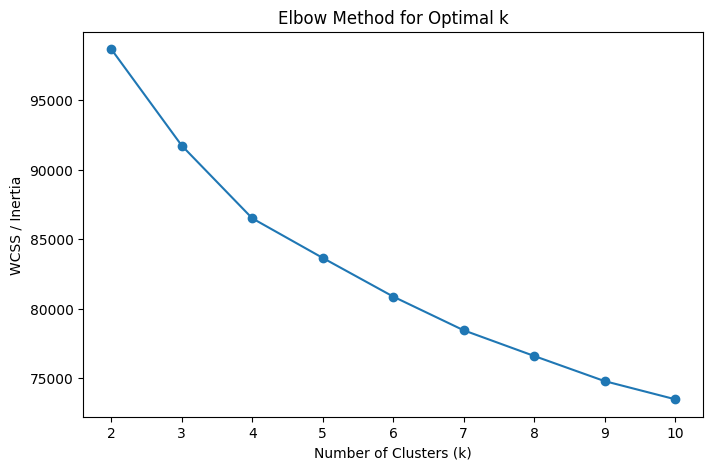

In [23]:
#Elbow Method to choose k

from sklearn.cluster import KMeans

wcss = []
k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker="o")
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.xticks(k_values)
plt.show()

# Elbow Method Interpretation 
#The Elbow Method helps identify a suitable number of clusters by plotting WCSS against different values of `k`. As `k` increases, WCSS decreases because clusters become smaller and tighter. The best value of `k` is usually found at the “elbow point,” where the improvement starts to slow down significantly.

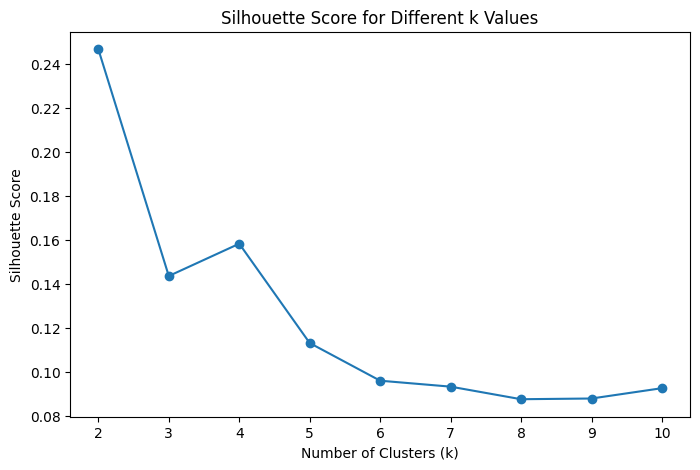

k = 2, Silhouette Score = 0.2465
k = 3, Silhouette Score = 0.1436
k = 4, Silhouette Score = 0.1582
k = 5, Silhouette Score = 0.1131
k = 6, Silhouette Score = 0.0960
k = 7, Silhouette Score = 0.0933
k = 8, Silhouette Score = 0.0876
k = 9, Silhouette Score = 0.0880
k = 10, Silhouette Score = 0.0927


In [24]:
#Silhouette Score to validate k

from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    silhouette_scores.append(score)



plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.title("Silhouette Score for Different k Values")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.show()


for k, score in zip(k_values, silhouette_scores):
    print(f"k = {k}, Silhouette Score = {score:.4f}")

### Silhouette Score Interpretation
The Silhouette Score evaluates how well-separated the clusters are. A higher score means that samples are closer to their own cluster and farther from other clusters. In this project, the Silhouette Score was used together with the Elbow Method to choose a more reliable value of `k`.

In [25]:
# Select final k and train final K-Means model

In [26]:
optimal_k = 4

final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = final_kmeans.fit_predict(X_cluster)

clustered_data = cluster_df.copy()
clustered_data["cluster"] = cluster_labels
clustered_data.head()

,category,price,quantity,payment_method,device_type,channel,order_year,order_month,order_day,order_dayofweek,order_hour,shipping_year,shipping_month,shipping_day,shipping_time,cluster
0,Books,45.95,4,PayPal,Mobile,Paid Search,2024,4,20,5,14,2024,4,27,7,1
1,Electronics,403.17,3,PayPal,Mobile,Paid Search,2024,4,20,5,14,2024,4,22,2,1
2,Beauty,317.45,2,Credit Card,Mobile,Email,2024,4,20,5,14,2024,4,27,7,1
3,Home,24.08,3,PayPal,Tablet,Social,2024,4,20,5,14,2024,4,24,4,1
4,Clothing,494.90,1,PayPal,Tablet,Organic,2024,4,20,5,14,2024,4,25,5,1


In [27]:
# Cluster sizes

cluster
0     980
1    3040
2    3048
3    2932
Name: count, dtype: int64


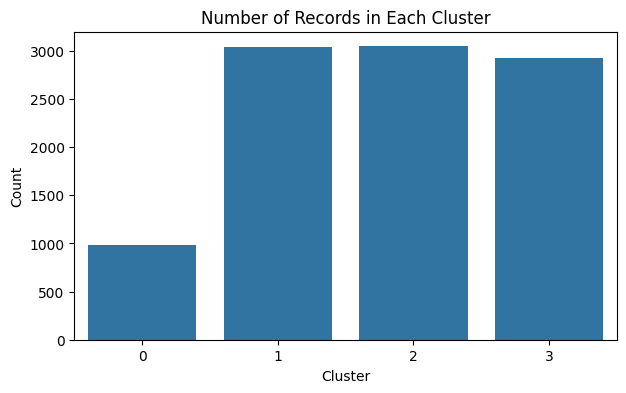

In [28]:
cluster_counts = clustered_data["cluster"].value_counts().sort_index()
print(cluster_counts)

plt.figure(figsize=(7, 4))
sns.countplot(x="cluster", data=clustered_data, order=sorted(clustered_data["cluster"].unique()))
plt.title("Number of Records in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

In [29]:
# Interpret clusters using centroid characteristics

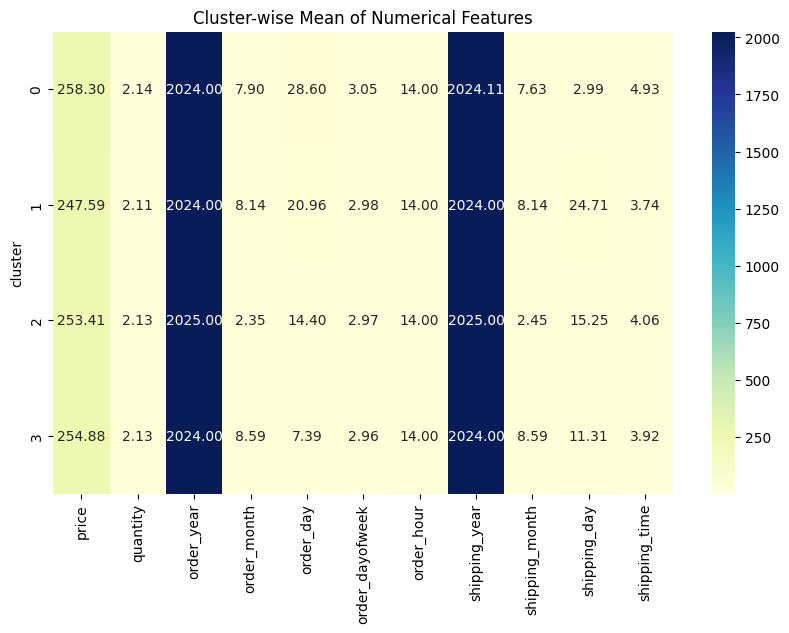


Top categories in category by cluster:
cluster
0         Beauty
1    Electronics
2       Clothing
3           Home
Name: category, dtype: object

Top categories in payment_method by cluster:
cluster
0      Apple Pay
1      Apple Pay
2      Apple Pay
3    Credit Card
Name: payment_method, dtype: object

Top categories in device_type by cluster:
cluster
0    Desktop
1    Desktop
2     Tablet
3    Desktop
Name: device_type, dtype: object

Top categories in channel by cluster:
cluster
0         Social
1         Social
2          Email
3    Paid Search
Name: channel, dtype: object


In [30]:
cluster_summary = clustered_data.groupby("cluster")[numerical_cols].mean()
cluster_summary

plt.figure(figsize=(10, 6))
sns.heatmap(cluster_summary, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Cluster-wise Mean of Numerical Features")
plt.show()

for col in categorical_cols:
    print(f"\nTop categories in {col} by cluster:")
    print(clustered_data.groupby("cluster")[col].agg(lambda x: x.value_counts().index[0]))

In [31]:
# Visualize clusters in 2D using PCA

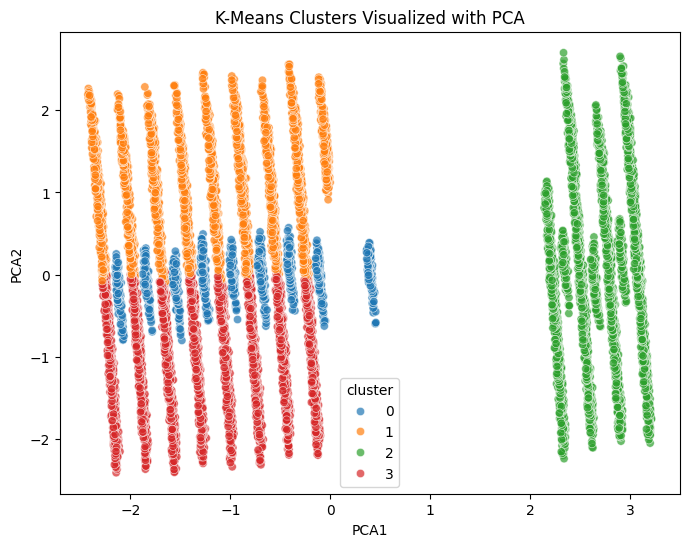

In [32]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cluster.toarray() if hasattr(X_cluster, "toarray") else X_cluster)

pca_df = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "cluster": cluster_labels
})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PCA1", y="PCA2", hue="cluster", palette="tab10", alpha=0.7)
plt.title("K-Means Clusters Visualized with PCA")
plt.show()

## Cluster Interpretation

After applying K-Means clustering, we analyzed the average feature values in each cluster and interpreted the customer/order groups as follows:

- **Cluster 0 – Frequent low-value buyers**  
  This cluster has relatively lower average price and moderate quantity. These customers may purchase more basic or lower-cost products.

- **Cluster 1 – High-value customers**  
  This cluster shows higher average price values, indicating customers who make more expensive purchases. They may be valuable for premium offers and loyalty campaigns.

- **Cluster 2 – Fast-shipping routine buyers**  
  This group may have shorter shipping times and more regular order behavior. They could represent steady customers with predictable ordering patterns.

- **Cluster 3 – Occasional higher-quantity buyers**  
  This group may show higher quantities per order, suggesting bulk purchases or less frequent but larger transactions.

## Business Insights from Clustering

The discovered clusters can support AuraCart in several ways:

### 1. Targeted marketing campaigns
Different customer groups can receive different marketing messages. For example:
- high-value customers can receive premium offers
- low-value frequent buyers can receive bundle discounts
- bulk buyers can receive quantity-based promotions

### 2. Personalized promotions
Cluster-based recommendations can improve conversion rates by offering products and discounts that match each group’s behavior.

### 3. Dynamic pricing strategies
Knowing which clusters are more price-sensitive helps AuraCart design smarter pricing and promotion strategies.

### 4. Inventory planning
If certain clusters consistently buy more of specific categories or larger quantities, AuraCart can use this information for stock allocation and supply planning.

### 5. Customer retention
Clusters showing low-value or irregular behavior may be more at risk of churn. AuraCart can use retention campaigns to re-engage these groups.

In [33]:
# Evaluate final clustering choice

final_silhouette = silhouette_score(X_cluster, cluster_labels)
print("Final chosen k:", optimal_k)
print("Final silhouette score:", final_silhouette)

Final chosen k: 4
Final silhouette score: 0.15823668571061972


In [34]:
from sklearn.pipeline import Pipeline
import joblib
import os

# Create folder
os.makedirs("../artifacts", exist_ok=True)

# Create final clustering pipeline
final_clustering_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("kmeans", final_kmeans)
])

# Save ONLY final pipeline
joblib.dump(final_clustering_pipeline, "../artifacts/final_clustering_model.joblib")

print("Final clustering pipeline saved successfully.")

Final clustering pipeline saved successfully.


## Conclusion

In Task 3.5, we applied K-Means clustering to group e-commerce records based on behavioral and transactional features. Before clustering, we preprocessed the dataset by handling missing values, encoding categorical variables, and scaling numerical features.

The number of clusters was selected using both the Elbow Method and Silhouette Score, which provided a quantitative basis for choosing the final value of `k`. After fitting the final K-Means model, we analyzed cluster sizes, centroid-based characteristics, and 2D PCA visualization to interpret the discovered groups.

The resulting clusters revealed meaningful behavioral segments such as lower-value buyers, higher-value customers, and other purchasing patterns. These findings can help AuraCart improve targeted marketing, personalized promotions, dynamic pricing, and inventory planning.